## Solução do Exemplo 1 - Reservatório de Cheias

Resolução via método das diferenças finitas da equação:

$$
\begin{aligned}
\frac{\mathrm{d} H}{\mathrm{~d} t}+b H^{3 / 2} &=f(t) \\
b &=\frac{\alpha \sqrt{g} L}{A}, \quad f(t)=\frac{I(t)}{A}
\end{aligned}
$$

Com condição inicial $H(0) = 0$ e $f(t)$ variando como:

$$
I(t)=\left\{\begin{array}{ll}
t / 360, & 0 \leq t \leq 3600 \\
50 / 3-t / 540 & 3600<t \leq 9000
\end{array}\right.
$$

Discretização em diferenças finitas:

$$
\frac{H_{n+1} - H_{n}}{\Delta t} + b H_n^{3/2} = f(t_n)
$$

$$
H_{n+1} = H_n + \Delta t \left[f(t_n)- b H_n^{3/2}\right]
$$


In [1]:
from math import sqrt
import numpy as np

In [2]:
# Área do reservatório
A    = 100000.0 # m2
alfa = 0.493
g    = 9.81
L    = 20.0
b    = alfa*sqrt(g)*L/A

In [3]:
# hidrógrafa afluente (m3/s/m2)
def f(t):
  if t <= 3600:
    return (t/360.0)/A
  elif t <= 9000:
    return (50.0/3.0 - t/540.0)/A
  else:
    return 0.0

In [4]:
Alturas   = []
Qafluente = []
Vazoes    = []
Tempo     = []

Discretização em diferenças finitas:

$$
\frac{H_{n+1} - H_{n}}{\Delta t} + b H_n^{3/2} = f(t_n)
$$

$$
H_{n+1} = H_n + \Delta t \left[f(t_n)- b H_n^{3/2}\right]
$$


In [5]:
tempo = 0
H = 0
deltat = 60
while tempo < 36000:
  #print(tempo)
  tempo = tempo + deltat
  I = A*f(tempo)
  H = H + deltat*(f(tempo)-b*H**1.5)
  Q = b*A*H**1.5
  Alturas.append(H)
  Vazoes.append(Q)
  Tempo.append(tempo)
  Qafluente.append(I)


In [6]:
#Tempo

In [7]:
# Importando as bibliotecas
import numpy
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
t_min = np.array(Tempo)/60
q_afl = np.array(Qafluente)
q_efl = np.array(Vazoes)

In [9]:
len(t_min)

600

In [10]:
tempo_visualizacao = 500

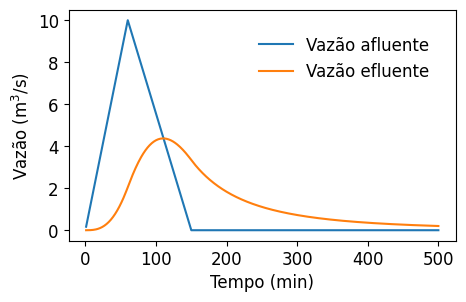

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.tick_params(axis='both', labelsize=12) #increase font size for ticks
plt.ylabel(r'Vazão (m$^3$/s)', fontsize=12) #y label
plt.xlabel(r'Tempo (min)', fontsize=12) #y label
ax.plot(t_min[0:tempo_visualizacao], q_afl[0:tempo_visualizacao], label='Vazão afluente')
ax.plot(t_min[0:tempo_visualizacao], q_efl[0:tempo_visualizacao], label='Vazão efluente')
ax.legend()
ax.legend(loc="upper right",bbox_to_anchor=(0.97, 0.95), frameon=False, fontsize=12)
plt.savefig('vazoes.pdf', dpi = 300, bbox_inches='tight')
plt.show();